# Spike responses to natural images and movies

This notebook generates the plots for Figure 2. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [4]:
import os

import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
dark_blue = "#1f78b4"
dark_orange = "#ff7f00"

In [6]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

In [7]:
all_spike_stats = analysis.AllDatasetSpikeStats(root)

## Spike raster

In [9]:
def plot_frame(frame, ax):
    ax.imshow(frame, vmin=-2, vmax=2, cmap="Greys")
    ax.spines["right"].set_linewidth(2)
    ax.spines["top"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

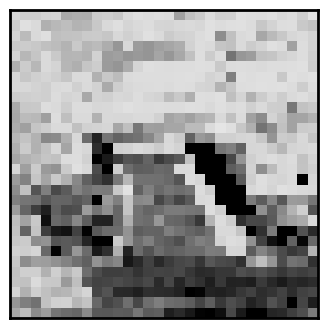

In [10]:
# Image frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

plot_frame(all_spike_stats.sal_img_stats.x[0, 0][0], ax)

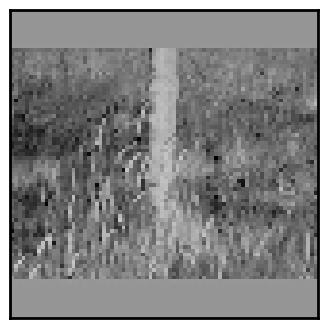

In [11]:
# Movie frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

plot_frame(all_spike_stats.mouse_movie_stats.x[0, 0][0], ax)

In [40]:
def plot_raster(x, y, title, x_max, x_max_v, y_max, ylabel, ax):
    ax.scatter(x, y, s=0.5, c="black")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    labelsize = 30
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_title(title, fontsize=30, pad=12)
    ax.set_xlim([0, x_max])
    ax.set_ylim([0, y_max])
    ax.set_xticks([0, x_max])
    ax.set_xticklabels([0, x_max_v])
    ax.set_yticks([0, y_max])
    ax.set_yticklabels([0, y_max])
    ax.set_ylabel(ylabel, fontsize=30, labelpad=8)

## Spike stats

In [30]:
def plot_natural_spike_stats(data_df, y_label, yticks, palette, ax):
    print(f"palette={palette}")
    sns.barplot(data_df, x="animal", y="y", errorbar=("se"), errwidth=6, palette=palette, ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs, rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=fs, labelpad=8)
    ax.set_ylim(0, yticks[-1])
    ax.set_yticks(yticks)
    
    ax.legend().set_visible(False)

In [31]:
firing_rate_df = all_spike_stats.get_spike_rate_df(img=False)
cv_df = all_spike_stats.get_cv_df(img=False)

## Image stats subplot

palette=['#1f78b4', '#1f78b4', '#ff7f00']
palette=['#1f78b4', '#1f78b4', '#ff7f00']


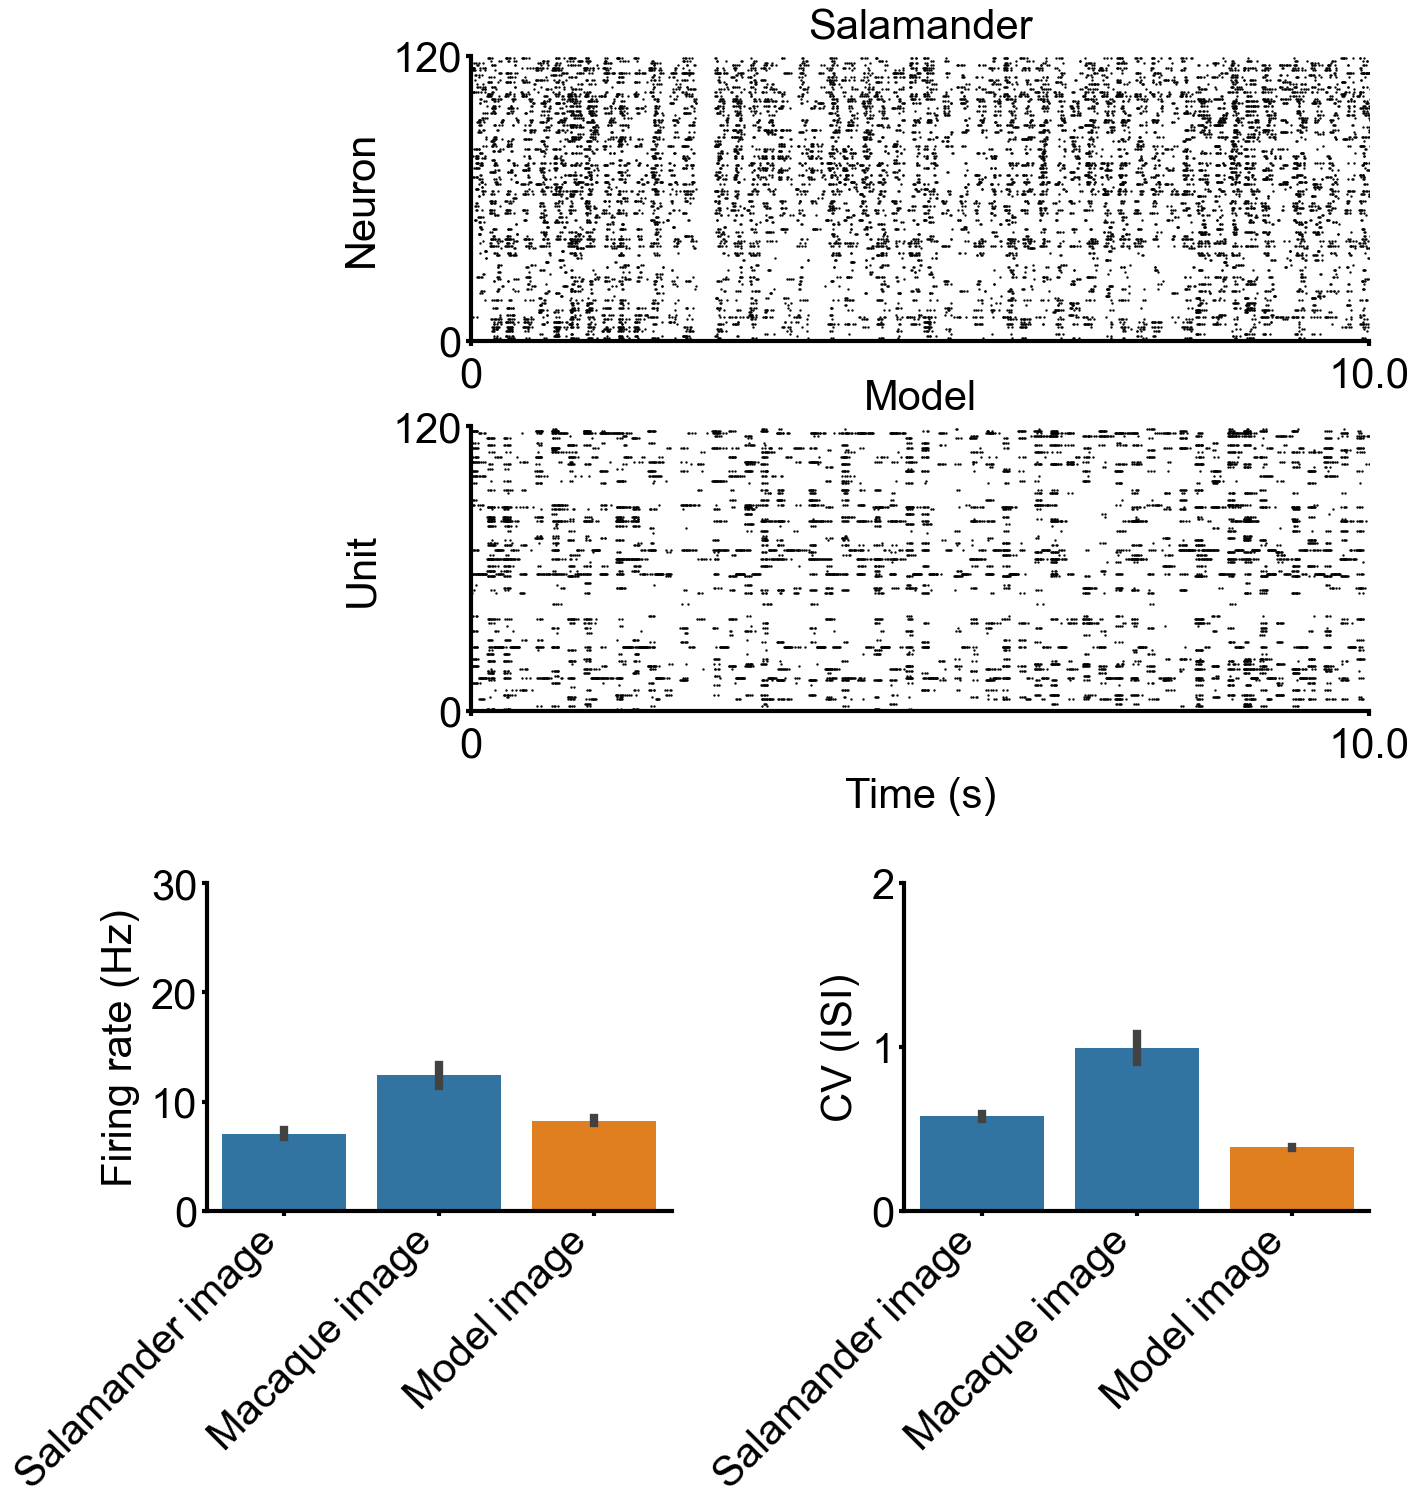

In [33]:
fig = plt.figure(figsize=(15, 15))
fig_spec = gridspec.GridSpec(2, 1, wspace=0, hspace=0.35, height_ratios=[1, 0.5])
top_spec = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[0], width_ratios=[0.25, 0.85], wspace=0)
top_spec = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=top_spec[1], height_ratios=[0.5, 0.5], hspace=0.3)
bottom_spec = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[1], width_ratios=[1, 1], wspace=0.5)

# Top
ax = plt.Subplot(fig, top_spec[0])
plot_raster(*all_spike_stats.sal_img_stats.get_exp_spike_times(), "Salamander", 2400, "10.0", 120, "Neuron", ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, top_spec[1])
plot_raster(*all_spike_stats.sal_img_stats.get_pred_spike_times(120, 42), "Model", 2400, "10.0", 120, "Unit", ax)
ax.set_xlabel("Time (s)", fontsize=30, labelpad=8)
fig.add_subplot(ax)

# Bottom
firing_rate_df = all_spike_stats.get_spike_rate_df(img=True)
cv_df = all_spike_stats.get_cv_df(img=True)

ax = plt.Subplot(fig, bottom_spec[0])
plot_natural_spike_stats(firing_rate_df, "Firing rate (Hz)", [0, 10, 20, 30], [dark_blue, dark_blue, dark_orange], ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, bottom_spec[1])
plot_natural_spike_stats(cv_df, "CV (ISI)", [0, 1, 2], [dark_blue, dark_blue, dark_orange], ax)
fig.add_subplot(ax)
plt.savefig(f"{root}/figures/fig2/image_stats.svg", format="svg", transparent=False, bbox_inches="tight")

In [34]:
model_img_firing = firing_rate_df[firing_rate_df["animal"] == "Model image"]["y"].values
model_img_cvisi = cv_df[cv_df["animal"] == "Model image"]["y"].values

## Movie stats subplot

palette=['#1f78b4', '#1f78b4', '#1f78b4', '#ff7f00']
palette=['#1f78b4', '#1f78b4', '#1f78b4', '#ff7f00']


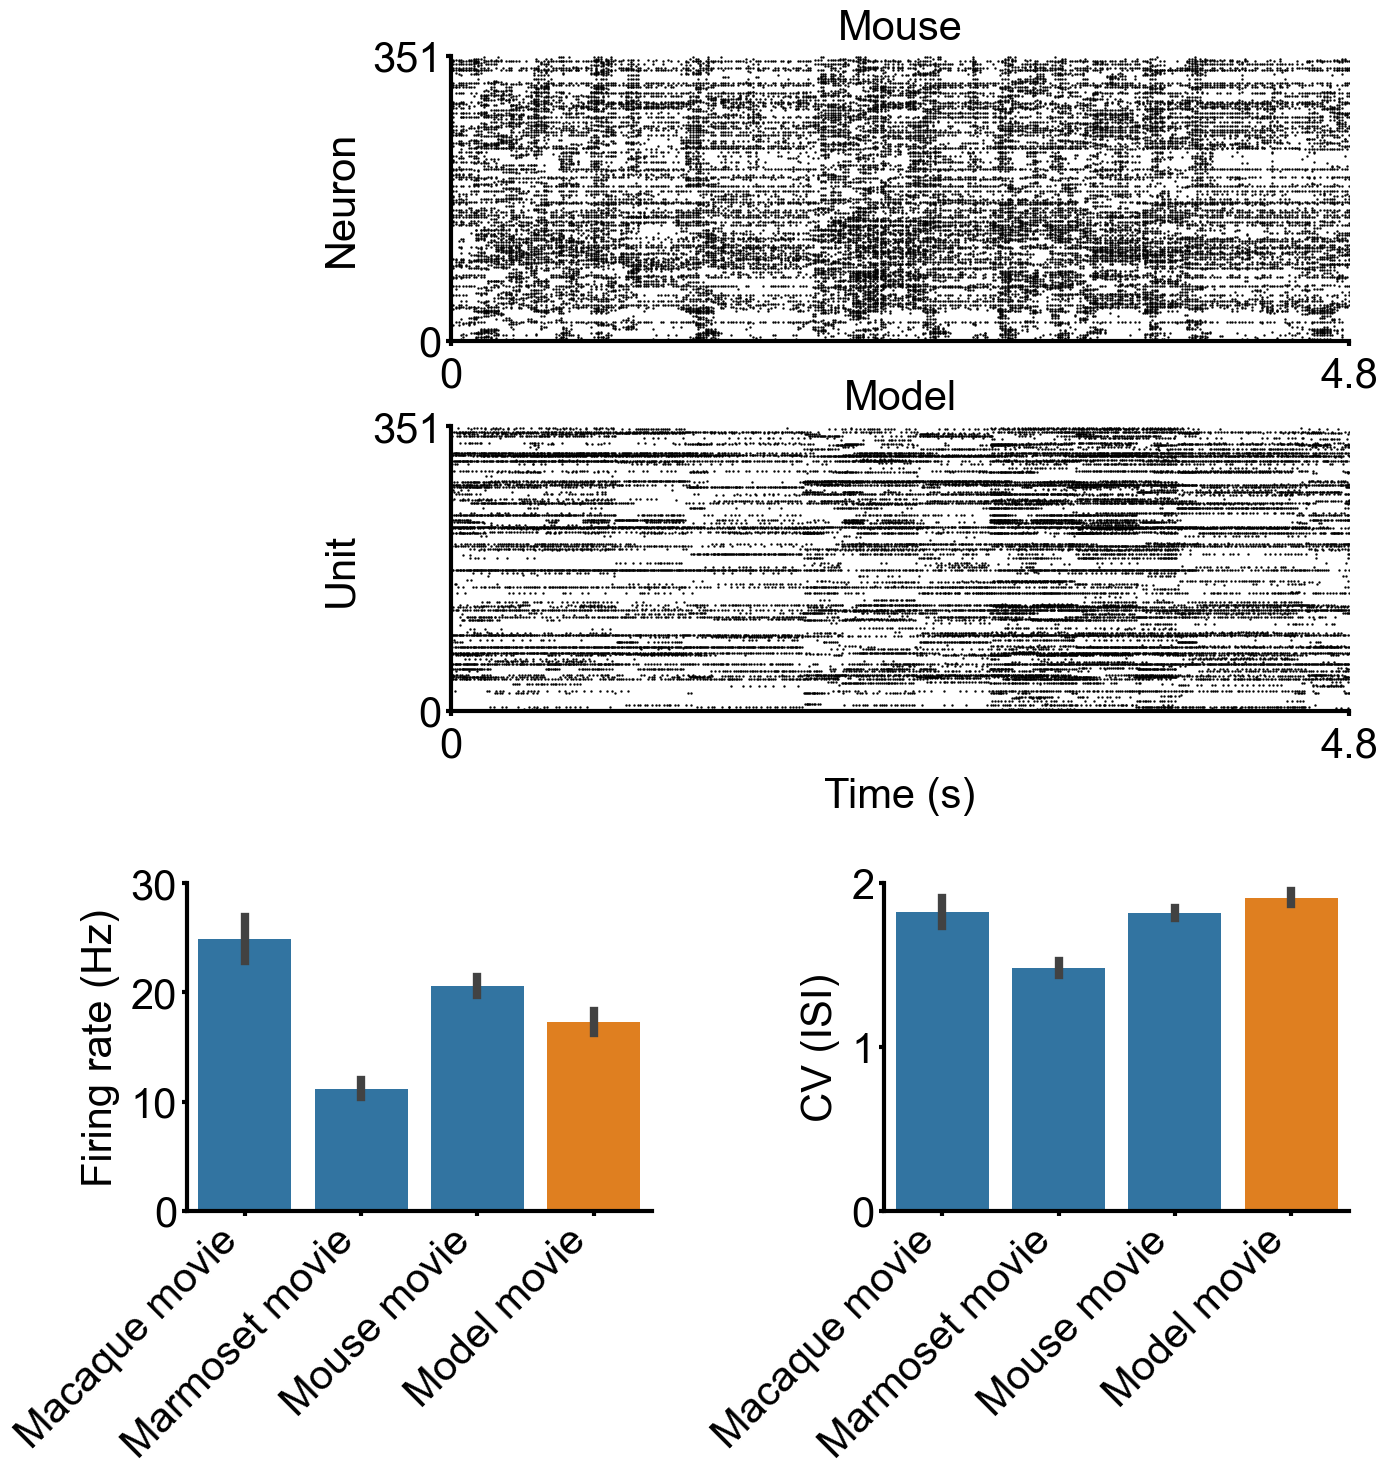

In [35]:
fig = plt.figure(figsize=(15, 15))
fig_spec = gridspec.GridSpec(2, 1, wspace=0, hspace=0.35, height_ratios=[1, 0.5])
top_spec = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[0], width_ratios=[0.25, 0.85], wspace=0)
top_spec = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=top_spec[1], height_ratios=[0.5, 0.5], hspace=0.3)
bottom_spec = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[1], width_ratios=[1, 1], wspace=0.5)

# Top
ax = plt.Subplot(fig, top_spec[0])
plot_raster(*all_spike_stats.mouse_movie_stats.get_exp_spike_times(), "Mouse", 1152, "4.8", 351, "Neuron", ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, top_spec[1])
plot_raster(*all_spike_stats.mouse_movie_stats.get_pred_spike_times(351, 42), "Model", 1152, "4.8", 351, "Unit", ax)
ax.set_xlabel("Time (s)", fontsize=30, labelpad=8)
fig.add_subplot(ax)

# Bottom
firing_rate_df = all_spike_stats.get_spike_rate_df(img=False)
cv_df = all_spike_stats.get_cv_df(img=False)

ax = plt.Subplot(fig, bottom_spec[0])
plot_natural_spike_stats(firing_rate_df, "Firing rate (Hz)", [0, 10, 20, 30], [dark_blue, dark_blue, dark_blue, dark_orange], ax)
fig.add_subplot(ax)

ax = plt.Subplot(fig, bottom_spec[1])
plot_natural_spike_stats(cv_df, "CV (ISI)", [0, 1, 2], [dark_blue, dark_blue, dark_blue, dark_orange], ax)
fig.add_subplot(ax)
plt.savefig(f"{root}/figures/fig2/movie_stats.svg", format="svg", transparent=False, bbox_inches="tight")

In [37]:
model_movie_firing = firing_rate_df[firing_rate_df["animal"] == "Model movie"]["y"].values
model_movie_cvisi = cv_df[cv_df["animal"] == "Model movie"]["y"].values

## Statistical tests

In [38]:
U1, p = mannwhitneyu(model_img_firing, model_movie_firing, alternative="less")
print(U1)
print(f"model_img_firing={model_img_firing.mean()}")
print(f"model_movie_firing={model_movie_firing.mean()}")
print(p)

559462.0
model_img_firing=8.272139306159483
model_movie_firing=17.272483934164047
6.017109760410685e-14


In [41]:
U1, p = mannwhitneyu(model_img_cvisi, model_movie_cvisi, alternative="less", nan_policy="omit")
print(U1)
print(f"model_img_firing={np.nanmean(model_img_cvisi)}")
print(f"model_movie_firing={np.nanmean(model_movie_cvisi)}")
print(p)

2473.0
model_img_firing=0.38728707059030265
model_movie_firing=1.911830870408591
1.873999475148593e-166
